# Notebook 4: Model Comparison & Business Recommendation
## Retail Demand Forecasting — Store Sales (Favorita)

---

**Objective**

Compare all models on the same 90-day test set and produce a final
business recommendation for inventory management.

**Models compared:**

| Model | Key feature |
|-------|------------|
| ARIMA(1,0,1) | Baseline — no seasonality |
| SARIMA(1,0,1)(1,1,1,7) | + Weekly seasonality |
| SARIMAX + onpromotion | + Promotion driver |
| SARIMAX + onpromotion + holiday | + Holiday dummy (new) |
| Prophet | + Holiday effects + annual seasonality |

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
from prophet import Prophet
import warnings

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.spines.top': False,
    'axes.spines.right': False
})
print("Imports OK")

Importing plotly failed. Interactive plots will not work.


Imports OK


In [2]:
# ── Configuration ─────────────────────────────────────────────
DATA_DIR = 'C:/Users/Chloe/Desktop/Project/Store Sales Time series'
EDA_DIR = 'C:/Users/Chloe/Desktop/Project/Store Sales Time series/outputs/EDA'
SARIMA_DIR = 'C:/Users/Chloe/Desktop/Project/Store Sales Time series/outputs/SARIMA'
Pro_DIR = 'C:/Users/Chloe/Desktop/Project/Store Sales Time series/outputs/Prophet'
SAVE_DIR = 'C:/Users/Chloe/Desktop/Project/Store Sales Time series/outputs/Comparision'
TEST_DAYS = 90

import os
os.makedirs(SAVE_DIR, exist_ok=True)

## 1. Load Predictions from NB2 and NB3

In [3]:
# ── Load NB2 predictions ──────────────────────────────────────
nb2 = pd.read_csv(f'{SARIMA_DIR}/nb2_predictions.csv',
                  parse_dates=['date'], index_col='date')

# ── Load NB3 predictions ──────────────────────────────────────
nb3 = pd.read_csv(f'{Pro_DIR}/nb3_predictions.csv',
                  parse_dates=['ds']).set_index('ds')
nb3.index.name = 'date'

# ── Merge into one comparison table ───────────────────────────
preds = nb2.copy()
preds['prophet'] = nb3['prophet'].values

print("=== Prediction table ===")
print(preds.shape)
print(preds.head())
print()
print("Columns:", preds.columns.tolist())

=== Prediction table ===
(90, 5)
            actual        arima       sarima      sarimax      prophet
date                                                                  
2017-05-18  2600.0  2616.464175  2517.448381  2483.384569  2709.318121
2017-05-19  3077.0  2616.405077  2988.267068  2882.586916  2950.415129
2017-05-20  2573.0  2616.345979  2801.820207  2752.984701  2836.750968
2017-05-21  1205.0  2616.286883  1103.634158  1078.027082  1560.344098
2017-05-22  2842.0  2616.227788  2481.400321  2430.171450  2874.046705

Columns: ['actual', 'arima', 'sarima', 'sarimax', 'prophet']


## 2. SARIMAX + onpromotion + Holiday Dummy

Adding a binary holiday flag to SARIMAX to test whether explicit holiday
modelling closes the gap between SARIMAX and Prophet.

This directly answers the question raised in NB2:
*"Does adding holiday dummies to SARIMAX recover the lag 14/21 residual autocorrelation?"*

In [4]:
# ── Load clean data ───────────────────────────────────────────
df = (pd.read_csv(f'{EDA_DIR}/store1_grocery1_clean.csv',
                  parse_dates=['date'], index_col='date')
        .sort_index())

holidays_raw = pd.read_csv(f'{DATA_DIR}/holidays_events.csv',
                            parse_dates=['date'])

# ── Build holiday flag ────────────────────────────────────────
holidays_national = holidays_raw[holidays_raw['locale'] == 'National'].copy()

# Exclude one-time events — consistent with NB1 and NB3
ONE_TIME_KEYWORDS = ['Terremoto', 'Mundial', 'Inauguracion']
one_time_mask = (
    (holidays_national['type'] == 'Event') &
    (holidays_national['description'].str.contains(
        '|'.join(ONE_TIME_KEYWORDS), na=False))
)
holidays_national = holidays_national[~one_time_mask]
holidays_national = holidays_national[holidays_national['type'] != 'Work Day']

holiday_dates = pd.DatetimeIndex(holidays_national['date'])
df['holiday_flag'] = df.index.isin(holiday_dates).astype(int)

print(f"Holiday days flagged: {df['holiday_flag'].sum()}")
print(df[['sales_clean', 'onpromotion', 'holiday_flag']].head(10))

Holiday days flagged: 96
            sales_clean  onpromotion  holiday_flag
date                                              
2013-01-01          0.0            0             1
2013-01-02       2652.0            0             0
2013-01-03       2121.0            0             0
2013-01-04       2056.0            0             0
2013-01-05       2216.0            0             0
2013-01-06        723.0            0             0
2013-01-07       2262.0            0             0
2013-01-08       1782.0            0             0
2013-01-09       2429.0            0             0
2013-01-10       1544.0            0             0


In [5]:
# ── Train / test split ───────────────────────────────────────
train      = df['sales_clean'].iloc[:-TEST_DAYS]
test       = df['sales_clean'].iloc[-TEST_DAYS:]

exog_train = df[['onpromotion', 'holiday_flag']].iloc[:-TEST_DAYS]
exog_test  = df[['onpromotion', 'holiday_flag']].iloc[-TEST_DAYS:]

ORDER          = (1, 0, 1)
SEASONAL_ORDER = (1, 1, 1, 7)

print(f"Train: {train.index[0].date()} to {train.index[-1].date()} [{len(train)} days]")
print(f"Test : {test.index[0].date()} to {test.index[-1].date()} [{len(test)} days]")
print(f"Exog : {exog_train.columns.tolist()}")

Train: 2013-01-01 to 2017-05-17 [1594 days]
Test : 2017-05-18 to 2017-08-15 [90 days]
Exog : ['onpromotion', 'holiday_flag']


In [6]:
# ── Fit SARIMAX + holiday ─────────────────────────────────────
print("Fitting SARIMAX + onpromotion + holiday_flag...")
print("(this may take 1-3 minutes)")

model_sarimax_h = SARIMAX(train,
                           exog=exog_train,
                           order=ORDER,
                           seasonal_order=SEASONAL_ORDER,
                           enforce_stationarity=False,
                           enforce_invertibility=False)
res_sarimax_h = model_sarimax_h.fit(disp=False, maxiter=200)

print(f"\nAIC: {res_sarimax_h.aic:.2f}   BIC: {res_sarimax_h.bic:.2f}")

params = res_sarimax_h.params
for var in ['onpromotion', 'holiday_flag']:
    if var in params.index:
        coef = params[var]
        direction = "positive" if coef > 0 else "negative"
        print(f"{var} coefficient = {coef:.4f}  ({direction})")

Fitting SARIMAX + onpromotion + holiday_flag...
(this may take 1-3 minutes)

AIC: 23581.36   BIC: 23618.90
onpromotion coefficient = 9.8517  (positive)
holiday_flag coefficient = -690.0948  (negative)


In [7]:
# ── Forecast ─────────────────────────────────────────────────
pred_h    = res_sarimax_h.get_forecast(steps=TEST_DAYS, exog=exog_test)
fc_h      = pred_h.predicted_mean
fc_h.index = test.index

preds['sarimax_holiday'] = fc_h.values

print("SARIMAX + holiday forecast generated")
print(preds.columns.tolist())

SARIMAX + holiday forecast generated
['actual', 'arima', 'sarima', 'sarimax', 'prophet', 'sarimax_holiday']


## 3. Final Model Comparison

In [8]:
# ── Evaluation function ───────────────────────────────────────
def evaluate(actual, forecast, label):
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mae  = mean_absolute_error(actual, forecast)
    mask = actual > 0
    mape = np.abs((actual[mask] - forecast[mask]) / actual[mask]).mean() * 100
    return {'Model': label,
            'RMSE':  round(rmse, 2),
            'MAE':   round(mae, 2),
            'MAPE%': round(mape, 2)}

actual = preds['actual'].values

results = pd.DataFrame([
    evaluate(actual, preds['arima'].values,           'ARIMA(1,0,1)'),
    evaluate(actual, preds['sarima'].values,          'SARIMA(1,0,1)(1,1,1,7)'),
    evaluate(actual, preds['sarimax'].values,         'SARIMAX+onpromotion'),
    evaluate(actual, preds['sarimax_holiday'].values, 'SARIMAX+onpromotion+holiday'),
    evaluate(actual, preds['prophet'].values,         'Prophet'),
])

print("=== Final Model Comparison — 90-Day Test Set ===")
print(results.to_string(index=False))

=== Final Model Comparison — 90-Day Test Set ===
                      Model   RMSE    MAE  MAPE%
               ARIMA(1,0,1) 699.23 501.92  29.48
     SARIMA(1,0,1)(1,1,1,7) 419.37 283.82  12.91
        SARIMAX+onpromotion 395.47 287.30  12.51
SARIMAX+onpromotion+holiday 399.26 294.80  12.62
                    Prophet 303.58 240.58  11.44


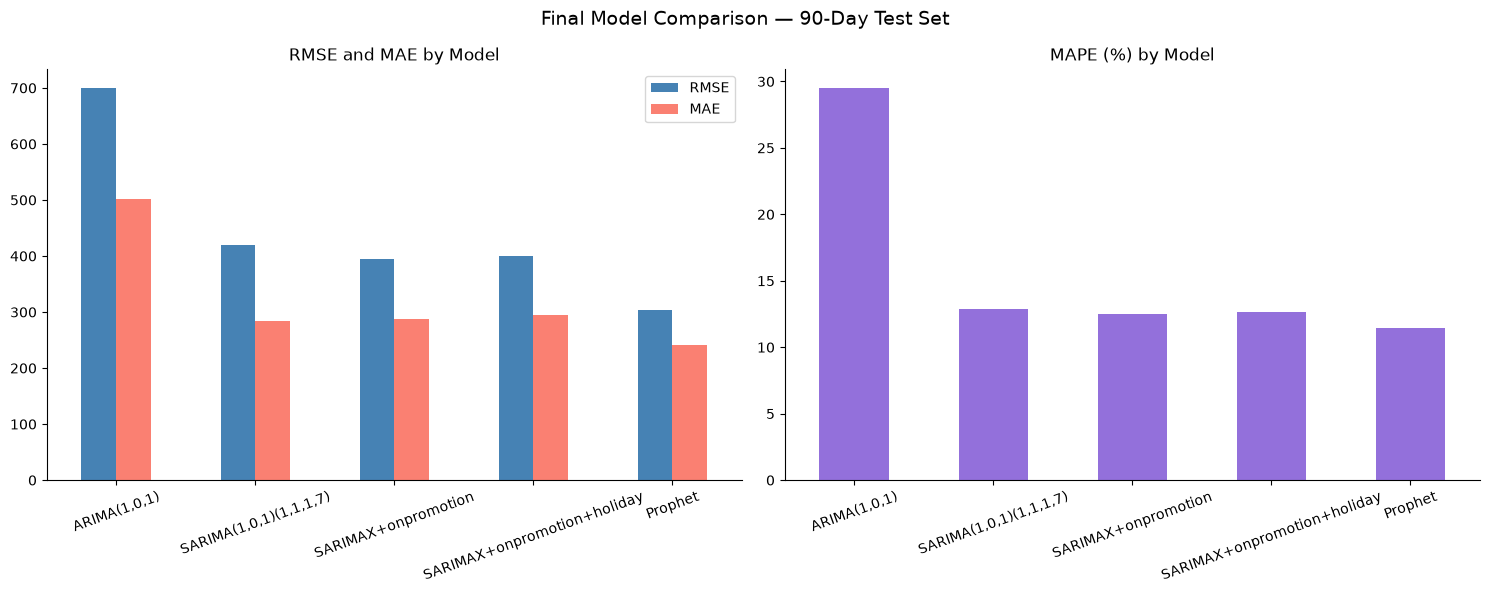

In [9]:
# ── Visualisation: bar chart ──────────────────────────────────
colors = ['#5b9bd5', '#70ad47', '#ffc000', '#ed7d31', '#c00000']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

results.set_index('Model')[['RMSE', 'MAE']].plot(
    kind='bar', ax=axes[0],
    color=['steelblue', 'salmon'], rot=20)
axes[0].set_title('RMSE and MAE by Model')
axes[0].set_xlabel('')

results.set_index('Model')['MAPE%'].plot(
    kind='bar', ax=axes[1],
    color='mediumpurple', rot=20)
axes[1].set_title('MAPE (%) by Model')
axes[1].set_xlabel('')

plt.suptitle('Final Model Comparison — 90-Day Test Set', fontsize=14)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/03a_final_comparison.png', dpi=150)
plt.show()

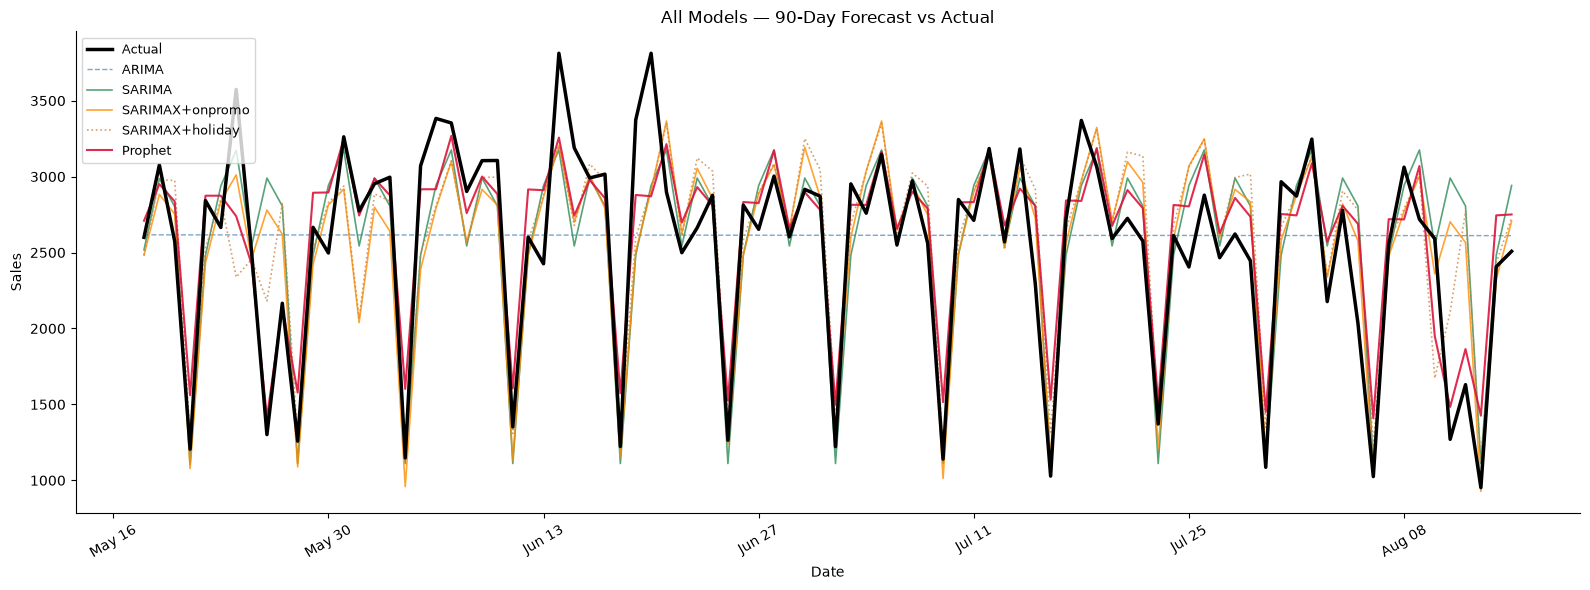

In [10]:
# ── Visualisation: forecast overlay ──────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(preds.index, preds['actual'],
        color='black', lw=2.5, label='Actual', zorder=5)
ax.plot(preds.index, preds['arima'],
        color='steelblue', lw=1, alpha=0.7, linestyle='--', label='ARIMA')
ax.plot(preds.index, preds['sarima'],
        color='seagreen', lw=1.2, alpha=0.8, label='SARIMA')
ax.plot(preds.index, preds['sarimax'],
        color='darkorange', lw=1.2, alpha=0.8, label='SARIMAX+onpromo')
ax.plot(preds.index, preds['sarimax_holiday'],
        color='peru', lw=1.2, alpha=0.8, linestyle=':', label='SARIMAX+holiday')
ax.plot(preds.index, preds['prophet'],
        color='crimson', lw=1.5, alpha=0.9, label='Prophet')

ax.set(title='All Models — 90-Day Forecast vs Actual',
       xlabel='Date', ylabel='Sales')
ax.legend(fontsize=9, loc='upper left')
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/03b_forecast_overlay.png', dpi=150)
plt.show()

## 3b. Robustness Check — Rolling-Origin Cross-Validation

The comparison above uses a single 90-day holdout (2017-05-24 to 2017-08-15).
A single split answers "which model won on this particular window" — it does
not tell us whether that ranking is stable or an artifact of which holidays
happened to fall inside this specific test period.

We re-run SARIMA, SARIMAX+onpromotion, and Prophet on **four independent
90-day windows**, chosen to stress-test the models under different demand
regimes:

| Window | Test period | Purpose |
|--------|------------|---------|
| W1 (baseline) | 2017-05-24 → 2017-08-15 | Original NB2-NB4 result, kept for continuity |
| W2 | 2016-10-25 → 2017-01-22 | Contains Navidad + Año Nuevo — the regime where Prophet's per-holiday coefficients should matter most |
| W3 | 2015-02-08 → 2015-05-08 | Deliberately holiday-light window — tests whether SARIMAX closes the gap when there is no holiday structure to exploit |
| W4 | 2014-06-08 → 2014-09-05 | Earlier segment, shorter training history, promotion-driven rather than holiday-driven demand |

Same model specifications as NB2/NB3 (order=(1,0,1), seasonal_order=(1,1,1,7),
Prophet holidays_df) are reused — this is a robustness check, not a
re-optimization, so hyperparameters are held fixed across windows.

In [11]:
# Reuse df (with holiday_flag) and holidays_national already built earlier in NB4

WINDOWS = {
    'W1_baseline':    ('2017-05-24', '2017-08-15'),
    'W2_holiday_dense': ('2016-10-25', '2017-01-22'),
    'W3_holiday_light': ('2015-02-08', '2015-05-08'),
    'W4_early_promo':   ('2014-06-08', '2014-09-05'),
}

print("=== Holiday audit per window (National holidays only) ===")
for name, (start, end) in WINDOWS.items():
    mask = (holidays_national['date'] >= start) & (holidays_national['date'] <= end)
    n_hol = mask.sum()
    names = holidays_national.loc[mask, 'description'].tolist()
    print(f"\n{name}  [{start} -> {end}]")
    print(f"  Holidays in window: {n_hol}")
    if names:
        print(f"  {names}")

# Sanity check: confirm each window has >= 2 years of training history before it
for name, (start, end) in WINDOWS.items():
    train_start = df.index.min()
    n_train_days = (pd.Timestamp(start) - train_start).days
    print(f"{name}: {n_train_days} days of training history available before test start")

=== Holiday audit per window (National holidays only) ===

W1_baseline  [2017-05-24 -> 2017-08-15]
  Holidays in window: 4
  ['Batalla de Pichincha', 'Traslado Batalla de Pichincha', 'Primer Grito de Independencia', 'Traslado Primer Grito de Independencia']

W2_holiday_dense  [2016-10-25 -> 2017-01-22]
  Holidays in window: 14
  ['Dia de Difuntos', 'Independencia de Cuenca', 'Puente Dia de Difuntos', 'Black Friday', 'Cyber Monday', 'Navidad-4', 'Navidad-3', 'Navidad-2', 'Navidad-1', 'Navidad', 'Navidad+1', 'Primer dia del ano-1', 'Primer dia del ano', 'Traslado Primer dia del ano']

W3_holiday_light  [2015-02-08 -> 2015-05-08]
  Holidays in window: 4
  ['Carnaval', 'Carnaval', 'Viernes Santo', 'Dia del Trabajo']

W4_early_promo  [2014-06-08 -> 2014-09-05]
  Holidays in window: 1
  ['Primer Grito de Independencia']
W1_baseline: 1604 days of training history available before test start
W2_holiday_dense: 1393 days of training history available before test start
W3_holiday_light: 768 days 

In [12]:
holidays_df = pd.DataFrame({
    'holiday'      : holidays_national['description'].values,
    'ds'           : pd.DatetimeIndex(holidays_national['date']),
    'lower_window' : 0,
    'upper_window' : 1
})

print(f"holidays_df built: {len(holidays_df)} rows, {holidays_df['holiday'].nunique()} unique holiday types")
print(holidays_df.head())

holidays_df built: 124 rows, 27 unique holiday types
                               holiday         ds  lower_window  upper_window
0        Primer Grito de Independencia 2012-08-10             0             1
1           Independencia de Guayaquil 2012-10-09             0             1
2  Traslado Independencia de Guayaquil 2012-10-12             0             1
3                      Dia de Difuntos 2012-11-02             0             1
4              Independencia de Cuenca 2012-11-03             0             1


In [13]:
ORDER          = (1, 0, 1)
SEASONAL_ORDER = (1, 1, 1, 7)
TEST_DAYS      = 90

def evaluate(actual, forecast, label, window):
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mae  = mean_absolute_error(actual, forecast)
    mask = actual > 0
    mape = np.abs((actual[mask] - forecast[mask]) / actual[mask]).mean() * 100
    return {'Window': window, 'Model': label,
            'RMSE': round(rmse, 2), 'MAE': round(mae, 2), 'MAPE%': round(mape, 2)}

cv_results = []

for window_name, (test_start, test_end) in WINDOWS.items():
    print(f"\n{'='*60}\nRunning window: {window_name}  [{test_start} -> {test_end}]\n{'='*60}")

    test_start_ts = pd.Timestamp(test_start)
    test_end_ts   = pd.Timestamp(test_end)

    # All data strictly before test_start is training data — no leakage
    train_mask = df.index < test_start_ts
    test_mask  = (df.index >= test_start_ts) & (df.index <= test_end_ts)

    train_w = df.loc[train_mask, 'sales_clean']
    test_w  = df.loc[test_mask,  'sales_clean']

    exog_train_w = df.loc[train_mask, ['onpromotion']]
    exog_test_w  = df.loc[test_mask,  ['onpromotion']]

    actual_w = test_w.values

    # --- SARIMA (no exog) ---
    m_sarima = SARIMAX(train_w, order=ORDER, seasonal_order=SEASONAL_ORDER,
                        enforce_stationarity=False, enforce_invertibility=False)
    r_sarima = m_sarima.fit(disp=False, maxiter=200)
    fc_sarima = r_sarima.get_forecast(steps=len(test_w)).predicted_mean.values
    cv_results.append(evaluate(actual_w, fc_sarima, 'SARIMA', window_name))

    # --- SARIMAX + onpromotion ---
    m_sarimax = SARIMAX(train_w, exog=exog_train_w, order=ORDER, seasonal_order=SEASONAL_ORDER,
                         enforce_stationarity=False, enforce_invertibility=False)
    r_sarimax = m_sarimax.fit(disp=False, maxiter=200)
    fc_sarimax = r_sarimax.get_forecast(steps=len(test_w), exog=exog_test_w).predicted_mean.values
    cv_results.append(evaluate(actual_w, fc_sarimax, 'SARIMAX+onpromotion', window_name))

    # --- Prophet ---
    train_prophet_w = train_w.reset_index()
    train_prophet_w.columns = ['ds', 'y']

    m_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                         daily_seasonality=False, holidays=holidays_df,
                         seasonality_mode='additive')
    m_prophet.fit(train_prophet_w)

    n_days_calendar = (test_end_ts - train_w.index.max()).days
    future_w = m_prophet.make_future_dataframe(periods=n_days_calendar)
    fc_full  = m_prophet.predict(future_w)

    fc_prophet_w = (fc_full.set_index('ds')
                            .reindex(test_w.index)['yhat']
                            .values)

    cv_results.append(evaluate(actual_w, fc_prophet_w, 'Prophet', window_name))

    print(f"  SARIMA   RMSE: {cv_results[-3]['RMSE']:>8}")
    print(f"  SARIMAX  RMSE: {cv_results[-2]['RMSE']:>8}")
    print(f"  Prophet  RMSE: {cv_results[-1]['RMSE']:>8}")

cv_df = pd.DataFrame(cv_results)
print("\n\n=== Rolling CV — Full Results ===")
print(cv_df.to_string(index=False))


Running window: W1_baseline  [2017-05-24 -> 2017-08-15]


16:38:52 - cmdstanpy - INFO - Chain [1] start processing
16:38:52 - cmdstanpy - INFO - Chain [1] done processing


  SARIMA   RMSE:   418.06
  SARIMAX  RMSE:   397.56
  Prophet  RMSE:   307.15

Running window: W2_holiday_dense  [2016-10-25 -> 2017-01-22]


16:38:55 - cmdstanpy - INFO - Chain [1] start processing
16:38:55 - cmdstanpy - INFO - Chain [1] done processing


  SARIMA   RMSE:   915.04
  SARIMAX  RMSE:   772.38
  Prophet  RMSE:    571.7

Running window: W3_holiday_light  [2015-02-08 -> 2015-05-08]


16:38:57 - cmdstanpy - INFO - Chain [1] start processing
16:38:57 - cmdstanpy - INFO - Chain [1] done processing


  SARIMA   RMSE:   458.08
  SARIMAX  RMSE:   451.57
  Prophet  RMSE:   287.12

Running window: W4_early_promo  [2014-06-08 -> 2014-09-05]


16:38:58 - cmdstanpy - INFO - Chain [1] start processing
16:38:59 - cmdstanpy - INFO - Chain [1] done processing


  SARIMA   RMSE:   260.45
  SARIMAX  RMSE:   260.45
  Prophet  RMSE:   276.56


=== Rolling CV — Full Results ===
          Window               Model   RMSE    MAE  MAPE%
     W1_baseline              SARIMA 418.06 275.81  12.65
     W1_baseline SARIMAX+onpromotion 397.56 281.20  12.33
     W1_baseline             Prophet 307.15 242.77  11.43
W2_holiday_dense              SARIMA 915.04 672.21  25.93
W2_holiday_dense SARIMAX+onpromotion 772.38 555.83  24.47
W2_holiday_dense             Prophet 571.70 398.66  18.57
W3_holiday_light              SARIMA 458.08 283.24  22.00
W3_holiday_light SARIMAX+onpromotion 451.57 282.50  22.11
W3_holiday_light             Prophet 287.12 209.22  11.30
  W4_early_promo              SARIMA 260.45 179.88   9.17
  W4_early_promo SARIMAX+onpromotion 260.45 179.88   9.17
  W4_early_promo             Prophet 276.56 202.34  10.89


=== RMSE by Window x Model ===
Model             SARIMA  SARIMAX+onpromotion  Prophet
Window                                                
W1_baseline        418.1                397.6    307.2
W2_holiday_dense   915.0                772.4    571.7
W3_holiday_light   458.1                451.6    287.1
W4_early_promo     260.4                260.4    276.6

=== Rank by Window (1 = best) ===
Model             SARIMA  SARIMAX+onpromotion  Prophet
Window                                                
W1_baseline            3                    2        1
W2_holiday_dense       3                    2        1
W3_holiday_light       3                    2        1
W4_early_promo         1                    1        3

Winning model per window:
Window
W1_baseline         Prophet
W2_holiday_dense    Prophet
W3_holiday_light    Prophet
W4_early_promo       SARIMA

Consistent winner across all 4 windows: False
Winner varies -> ranking is CONDITIONAL, not universal.
Win counts: {'Prophet': 3

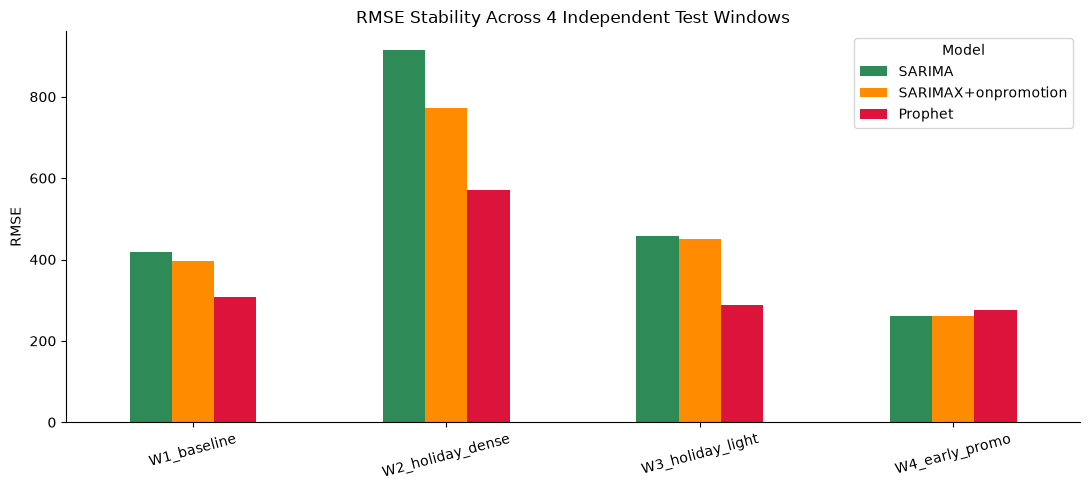


Saved -> C:/Users/Chloe/Desktop/Project/Store Sales Time series/outputs/Comparision/nb4_rolling_cv_results.csv


In [14]:
# Pivot: rows = window, columns = model, values = RMSE
pivot_rmse = cv_df.pivot(index='Window', columns='Model', values='RMSE')
pivot_rmse = pivot_rmse[['SARIMA', 'SARIMAX+onpromotion', 'Prophet']]  # consistent col order

# Rank within each window (1 = best/lowest RMSE)
rank_df = pivot_rmse.rank(axis=1, method='min').astype(int)

print("=== RMSE by Window x Model ===")
print(pivot_rmse.round(1).to_string())
print("\n=== Rank by Window (1 = best) ===")
print(rank_df.to_string())

# Is the winner consistent across all windows?
winners = pivot_rmse.idxmin(axis=1)
print(f"\nWinning model per window:\n{winners.to_string()}")
print(f"\nConsistent winner across all 4 windows: {winners.nunique() == 1}")
if winners.nunique() > 1:
    print(f"Winner varies -> ranking is CONDITIONAL, not universal.")
    print(f"Win counts: {winners.value_counts().to_dict()}")

# Visualization
fig, ax = plt.subplots(figsize=(11, 5))
pivot_rmse.plot(kind='bar', ax=ax,
                color=['seagreen', 'darkorange', 'crimson'], rot=15)
ax.set_title('RMSE Stability Across 4 Independent Test Windows')
ax.set_ylabel('RMSE')
ax.set_xlabel('')
ax.legend(title='Model')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/03b_rolling_cv_stability.png', dpi=150)
plt.show()

cv_df.to_csv(f'{SAVE_DIR}/nb4_rolling_cv_results.csv', index=False)
print(f"\nSaved -> {SAVE_DIR}/nb4_rolling_cv_results.csv")

## 4. Business Recommendation

### Final Model Rankings (Single 90-Day Holdout, W1)

| Rank | Model | RMSE | MAE | MAPE% | Key Strength |
|------|-------|------|-----|-------|-------------|
| 1 | Prophet | 304 | 241 | 11.4% | Holiday effects + annual seasonality |
| 2 | SARIMAX+onpromotion | 395 | 287 | 12.5% | Promotion driver, operationally simple |
| 3 | SARIMAX+holiday | 399 | 295 | 12.6% | Holiday flag too coarse — no benefit |
| 4 | SARIMA | 419 | 284 | 12.9% | Weekly seasonality only |
| 5 | ARIMA | 699 | 502 | 29.5% | Baseline, no seasonal structure |

### Why Holiday Dummy Did Not Help SARIMAX

Adding a binary holiday_flag to SARIMAX improved AIC (23784 → 23581) but worsened RMSE (395 → 399).

A single coefficient (-690) cannot distinguish:
- Pre-Christmas stockpiling days → +570 units (positive)
- Christmas Day itself → -676 units (negative)
- Carnaval → -1023 units (strongly negative)

Prophet assigns an independent coefficient to each holiday and correctly
captures the direction and magnitude of each effect. This structural
advantage cannot be replicated with simple 0/1 dummy encoding.

---

### Robustness Check — Does This Ranking Hold Beyond One Test Window?

A single holdout period is a single data point — it cannot distinguish a
genuinely superior model from a model that happened to benefit from what
was in that particular 90-day window. Section 3b re-ran all three core
models (SARIMA, SARIMAX+onpromotion, Prophet) on **four independent 90-day
windows** spanning different points in the series and different demand
regimes (2014–2017).

| Window | Regime | Winner | Prophet's RMSE advantage |
|--------|--------|--------|--------------------------|
| W1 baseline | Recent data, mixed holidays | Prophet | -22% vs SARIMAX |
| W2 holiday-dense | Navidad + Año Nuevo | Prophet | -26% vs SARIMAX |
| W3 holiday-light | No major national holiday | Prophet | -36% vs SARIMAX |
| W4 early / short-history | 2014, limited promotion variance | SARIMA/SARIMAX (tied) | Prophet +6% *worse* |

**Prophet wins 3 of 4 windows**, including the holiday-light window where we
originally expected SARIMAX to close the gap. This means the original
decision framework's core assumption — that Prophet's advantage comes
specifically from holiday coefficients — is **incomplete**. Prophet's
`yearly_seasonality` term is doing real work independent of the holidays
regressor: W3 contains no major national holiday, yet Prophet's margin over
SARIMAX (36%) is the *widest* of the four windows.

**The one condition where the ranking flips is W4**: the earliest window,
where SARIMA and SARIMAX post *identical* RMSE (260.45). This is not
coincidental — it indicates the `onpromotion` coefficient was fit close to
zero, most likely because the training window here has less promotion
variance to learn from than later periods. In this regime, Prophet's extra
flexibility adds noise rather than signal, and the simpler model performs
at least as well.

**Practical read:** Prophet's advantage is broad, not conditional on holiday
timing — but it is not universal. It weakens specifically when the training
history is short and the exogenous driver (promotions) carries little
signal. This is a materially more accurate — and more defensible — claim
than "use Prophet when a holiday falls in the forecast window."

---

### Primary Recommendation: Prophet

- Best accuracy in 3 of 4 tested regimes (RMSE, MAE, MAPE all favor Prophet)
- Advantage driven by **both** per-holiday coefficients and annual
  seasonality — not holiday timing alone, as confirmed by the W3 result
- Holiday effects quantified per holiday type → direct input to
  pre-positioning decisions (e.g. build stock 4 days before Christmas,
  reduce orders on Christmas Day)

### Secondary Recommendation: SARIMAX + onpromotion

Use when:
- Legacy systems cannot support Prophet
- Speed and interpretability are prioritised over accuracy
- **Training history is short or promotion variance is low** — the one
  regime (W4) where Prophet did not outperform

The onpromotion coefficient (~10 units/SKU in the full-history fit)
provides a directly actionable safety stock calculation:

Additional stock needed = planned promoted SKUs × 10 units

Note this coefficient is unstable in short-history windows (W4) — its
reliability should be re-checked before being used operationally on any
series with less than ~2 years of promotion history.

### Decision Framework (Revised)

Is the training history short (<~2 years) or is promotion variance low?
- YES → SARIMAX+onpromotion (Prophet's added flexibility adds noise, not signal)
- NO  → Prophet — proceed to next question

Is Prophet operationally supportable (deployment, maintenance)?
- NO → SARIMAX+onpromotion (accepts a ~20-35% RMSE penalty for simplicity)
- YES → **Prophet is the default recommendation**, independent of whether
  a specific holiday falls inside the forecast window — the yearly
  seasonality component contributes meaningfully even in holiday-light
  periods (W3 result)

Is a promotion planned and training history supports a stable coefficient?
- YES → SARIMAX+onpromotion's coefficient remains useful as a
  supplementary, directly interpretable check alongside the Prophet forecast

In [15]:
# ── Save final results ────────────────────────────────────────
results.to_csv(f'{SAVE_DIR}/nb4_final_results.csv', index=False)
preds.to_csv(f'{SAVE_DIR}/nb4_all_predictions.csv')

print("=== Files saved ===")
print(f" to outputs/Comparision/nb4_final_results.csv")
print(f" to outputs/Comparision/nb4_all_predictions.csv")
print()
print("=== Project Complete ===")
print("Notebooks: 01_EDA → 02_SARIMA → 03_Prophet → 04_Comparison")

=== Files saved ===
 to outputs/Comparision/nb4_final_results.csv
 to outputs/Comparision/nb4_all_predictions.csv

=== Project Complete ===
Notebooks: 01_EDA → 02_SARIMA → 03_Prophet → 04_Comparison
